# Asistente Conversacional Agentic RAG — Mundial 2026 + Plataforma 91

**Proyecto Final — Procesamiento de Lenguaje Natural**

**Autor:** Manolo Iniguez  
**Curso:** PLN — USFQ  
**Fecha:** 2026-05-17

---

## Resumen ejecutivo

Sistema Agentic RAG en español que responde preguntas sobre el **Mundial 2026** y la **plataforma 91 de predicciones** del autor (noventayuno.com), combinando dos corpus complementarios y un agente conversacional con **tool calling** que decide cual fuente consultar.

- **Corpus externo (Mundial):** 438 docs `.md` (Wikipedia ES + Reglamento FIFA 2026 + Kaggle + Calendario 104 partidos) → 4497 chunks.
- **Corpus interno (Plataforma 91):** 55 docs `.md` con frontmatter YAML → 316 chunks.
- **Embeddings:** OpenAI `text-embedding-3-small` (1536-dim).
- **LLM:** OpenAI `gpt-4o-mini`, `temperature=0`.
- **Framework:** LangGraph (`StateGraph` con 3 nodos, sin grader/rewrite).
- **Eval:** RAGAS 4 metricas + 2 custom sobre 40 Q/A reales.

**Resultado clave:** el agente Agentic supera al baseline RAG clasico en **3/4 metricas RAGAS** (Faithfulness +0.12, AnswerCorrectness +0.07, FactualCorrectness +0.09) y cumple **3/4 targets absolutos calibrados**. En preguntas multi-hop (que cruzan ambos corpus) el baseline obtiene 0.0/0.04/0.0/0.0 mientras el agente alcanza 0.875/0.655/0.685/0.508 — diferencia dramatica que valida la arquitectura Agentic vs RAG fijo.

## Tabla de contenidos

1. **Problema y objetivo**
2. **Arquitectura — Agentic RAG**
3. **Corpus y datos**
4. **Indexado vectorial (F5)**
5. **Agente — grafo LangGraph (F6)**
6. **Eval set (F7)**
7. **Resultados RAGAS (F8)**
8. **Demo en vivo**
9. **Conclusiones**
10. **Trabajo futuro**
11. **Referencias**

**Notebooks productivos del proyecto** (orden de ejecucion):

| Notebook | Fase | Output |
|---|---|---|
| `00-build-corpus-calendar2026.ipynb` | F4B | 104 docs calendario |
| `01-build-corpus-wikipedia.ipynb` | F3 | 174 docs Wikipedia ES |
| `02-build-corpus-reglamento.ipynb` | F3 | 53 docs Reglamento FIFA |
| `03-build-corpus-kaggle.ipynb` | F3 | 107 docs Kaggle |
| `04-build-index.ipynb` | F5 | Chroma 4813 chunks |
| `05-build-agent.ipynb` | F6 | Grafo LangGraph |
| `06-build-eval-set.ipynb` | F7 | `eval_set.jsonl` (40 Q/A) |
| `07-run-systems.ipynb` | F8a | `results_*.jsonl` |
| `08-eval-ragas.ipynb` | F8b | `ragas_scores.json` |
| **`09-entregable.ipynb`** | **F9** | **Este documento** |

## 1. Problema y objetivo

### Pregunta de negocio

El autor opera **noventayuno.com (91)**, una plataforma web donde usuarios hacen predicciones del Mundial 2026 (108 usuarios reales, 618 predicciones, 104 partidos, 48 selecciones, 16 estadios). Los usuarios necesitan responder preguntas como:

- *"¿En que estadio juega Argentina su primer partido y como predigo en la plataforma?"*
- *"¿Cuanto puntos gano si acierto el marcador exacto?"*
- *"¿Que dice el reglamento FIFA sobre la prorroga?"*

Estas mezclan **conocimiento del Mundial** (Wikipedia, reglamento, calendario) y **conocimiento de la plataforma** (reglas, sistema de puntaje, tribus, torneos).

### Objetivo del proyecto

Construir un **asistente conversacional en español** que responda esas preguntas con:

1. **Recuperacion fundamentada** (RAG): respuestas sustentadas por chunks de corpus reales, no alucinaciones del LLM.
2. **Decision automatica de fuente** (Agentic): el sistema elige por si mismo cual corpus consultar segun la pregunta, sin reglas hard-coded.
3. **Soporte multi-hop**: preguntas que requieren combinar ambos corpus deben funcionar en una sola interaccion.
4. **Evaluacion cuantitativa**: comparar contra un baseline RAG clasico con metricas estandar (RAGAS) para justificar la arquitectura.

### Restricciones autoimpuestas (Plan §8)

- **No matarse**: cada componente debe estar probado en literatura o clase.
- **Riesgo bajo**: priorizar estabilidad sobre tecnicas novedosas.
- **Datos reales en español**: no repetir el patron sintetico del Taller 3.
- **Estatico**: corpus pre-procesado, sin scraping en runtime.

## 2. Arquitectura — Agentic RAG

### Eleccion: ReAct + tool calling

Se eligio **Agentic RAG con patron ReAct** ([Yao et al. 2022](https://arxiv.org/abs/2210.03629)) sobre RAG clasico, basandose en:

- **Lectura L3** — *Agentic RAG: A Survey (2025)*: motiva uso de agentes cuando hay multiples fuentes heterogeneas.
- **Lectura L4** — *ReAct: Synergizing Reasoning and Acting in LLMs*: patron de razonamiento + tool calling que define el grafo del agente.
- **Semana 3 del curso** (`s3_p3.ipynb`, `s3_p5.ipynb`): patron LangGraph usado.

### Diagrama del grafo (NB05 §9)

```
          ┌────────────────────────────┐
  START → │ generate_query_or_respond  │
          └────────────┬───────────────┘
                       │
        ┌──────────────┴───────────────┐
        │ (no tool_calls)        (tool_calls)
        ↓                              ↓
       END                  ┌──────────────────┐
                            │ retrieve (ToolNode) │
                            │  ─ buscar_mundial   │
                            │  ─ buscar_plataforma│
                            └────────┬────────────┘
                                     ↓
                            ┌──────────────────┐
                            │ generate_answer  │
                            └────────┬─────────┘
                                     ↓
                                    END
```

### Decisiones arquitectonicas clave

| Decision | Eleccion | Razon |
|---|---|---|
| Framework | LangGraph `StateGraph` | Usado en S3 + Taller 3. Patron declarativo, observable. |
| LLM | `gpt-4o-mini` | Token del curso, estable, RAGAS-friendly. |
| Embeddings | `text-embedding-3-small` (OpenAI) | Multilingual nativo, dim 1536. Reemplazo `multilingual-e5-base` local que crasheaba kernel Windows. |
| Vector DB | Chroma `PersistentClient` | Local, sin servidor, suficiente para 4813 chunks. |
| Tools | 2 (`buscar_mundial`, `buscar_plataforma`) | Una por coleccion. LLM elige via docstrings. |
| **Sin grader+rewrite** | Removidos del grafo | Causaban loops infinitos en multi-hop. Reemplazados por prompt explicito "respuesta parcial honesta" en `generate_answer`. |
| Recursion limit | 4 | Suficiente para flow simplificado (max 3 pasos). |

## 3. Corpus y datos

Dos corpus complementarios, ambos en español, totalizando **493 documentos `.md`** procesables (~16 MB).

In [1]:
from __future__ import annotations

import json
import os
from collections import Counter
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
CORPUS_91 = PROJECT_ROOT / "Corpus_91"
CORPUS_MUNDIAL = PROJECT_ROOT / "Corpus_Mundial"

load_dotenv(PROJECT_ROOT / ".env")

# Conteo de archivos por subcarpeta
def count_md_recursive(root):
    out = {}
    for sub in sorted(root.iterdir()):
        if sub.is_dir():
            out[sub.name] = sum(1 for _ in sub.rglob("*.md"))
    return out


plat = count_md_recursive(CORPUS_91)
mund = count_md_recursive(CORPUS_MUNDIAL)

print("=" * 55)
print("CORPUS INTERNO — Corpus_91 (plataforma)")
print("=" * 55)
for k, v in plat.items():
    print(f"  {k:<22} {v:>3}")
print(f"  {'TOTAL':<22} {sum(plat.values()):>3}")

print("\n" + "=" * 55)
print("CORPUS EXTERNO — Corpus_Mundial")
print("=" * 55)
for k, v in mund.items():
    print(f"  {k:<22} {v:>3}")
print(f"  {'TOTAL':<22} {sum(mund.values()):>3}")

print(f"\nGRAN TOTAL: {sum(plat.values()) + sum(mund.values())} documentos .md")

CORPUS INTERNO — Corpus_91 (plataforma)
  identidad                1
  legal                    8
  monedas-tienda           4
  navegacion               3
  perfil-referidos         4
  predicciones             4
  privacidad               9
  rankings                 5
  registro                 2
  torneos                  9
  tribus                   6
  TOTAL                   55

CORPUS EXTERNO — Corpus_Mundial
  calendario-2026        104
  kaggle                 107
  reglamento-fifa         53
  wikipedia              174
  TOTAL                  438

GRAN TOTAL: 493 documentos .md


### Fuentes y procesamiento

**Corpus interno (plataforma 91):**
- Input: 10 `.txt` raw de paginas de noventayuno.com (general, predicciones, ranking, tribus, torneos, tienda, perfil, T&C, privacidad, registro).
- Output: 55 `.md` reorganizados por **tema atomico** (un concepto = un doc) en 11 subcarpetas, con frontmatter YAML (`titulo`, `tema`, `tipo`, `tags`, `fuente`).
- FAQs incluidas al final de cada doc tematico → el chunk de respuesta queda junto al contexto conceptual.

**Corpus externo (Mundial):**
- **Wikipedia ES** (174 docs): selecciones, jugadores, estadios, ediciones historicas, conceptos. Descargado via `wikipedia-api` (NB01).
- **Reglamento FIFA 2026** (53 docs): PDF oficial ES parseado a 1 preambulo + 52 articulos (NB02).
- **Kaggle Mundiales** (107 docs): combinado `abecklas/fifa-world-cup` (1930-2014) + `martj42/international-football-results` (2018-2022) → 22 ediciones + 85 equipos historicos. Linearizado a español con diccionarios de traduccion (NB03).
- **Calendario Mundial 2026** (104 docs): JSON oficial → un `.md` por partido con frontmatter rico (fecha, hora UTC/local, estadio, ciudad, fase, grupo, equipos). Equipos y fases traducidos al español (NB00).

## 4. Indexado vectorial (F5)

Pipeline en `notebooks/04-build-index.ipynb`:

1. **Loader** (`python-frontmatter`): parsea YAML + extrae metadata por doc. Sanitiza para Chroma (solo primitivos; listas → strings).
2. **Chunking** en Python puro (sin `langchain_text_splitters` que crashea el kernel en Windows):
   - `split_by_markdown_headers` corta por `#`/`##`/`###` y preserva header path en metadata.
   - `recursive_split` fallback para sub-chunks >2400 chars.
   - Filtro `min 40 chars` descarta headers huerfanos.
3. **Embeddings** con `OpenAIEmbeddings(model='text-embedding-3-small')`, batches de 256 chunks/request.
4. **Persistencia** en dos colecciones Chroma (`mundial`, `plataforma`) con `hnsw:space=cosine`.

### Resultados

| Coleccion | Docs | Chunks | Mediana chars/chunk | Max chars/chunk |
|---|---:|---:|---:|---:|
| plataforma | 55 | 316 | 214 | 1177 |
| mundial | 438 | 4497 | 1486 | 2597 |
| **TOTAL** | **493** | **4813** | — | — |

**Costo:** ~$0.05 USD (~2M tokens × $0.02/M). **Tiempo:** ~33s (embed 30s + Chroma insert 5s).

In [2]:
# Verificar Chroma desde disco
import chromadb

CHROMA_DIR = PROJECT_ROOT / "chroma_db"
client = chromadb.PersistentClient(path=str(CHROMA_DIR))
col_mundial = client.get_collection("mundial")
col_plataforma = client.get_collection("plataforma")
print(f"Chroma persistente en: {CHROMA_DIR}")
print(f"  - mundial:    {col_mundial.count():>5} chunks")
print(f"  - plataforma: {col_plataforma.count():>5} chunks")

Chroma persistente en: c:\Users\Administrador\Documents\MaestriaUSFQ\Procesamiento Lenguaje Natural\Proyecto Final\chroma_db
  - mundial:     4497 chunks
  - plataforma:   316 chunks


## 5. Agente — grafo LangGraph (F6)

Reconstruyo el agente aqui mismo (mismo codigo que NB05 §9) para que el notebook entregable sea **autocontenido** y permita demo en vivo en §8.

### Tools

Cada `@tool` envuelve una coleccion Chroma. El LLM elige cual llamar leyendo el docstring (no hay reglas hard-coded de routing — esa decision es agentic).

- `buscar_mundial(query)` → coleccion `mundial`. Mundial 2026, calendario, jugadores, estadios, reglamento FIFA, historia.
- `buscar_plataforma(query)` → coleccion `plataforma`. Features de noventayuno.com.

Ambas con `k=5` chunks por query, truncados a 800 chars cada uno para no saturar contexto.

In [3]:
from langchain_core.tools import tool
from langchain_core.messages import ToolMessage, AIMessage
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition

OPENAI_MODEL = os.getenv("OPENAI_MODEL", "gpt-4o-mini")
EMBEDDING_MODEL = "text-embedding-3-small"
TOP_K_TOOL = 5
TOOL_MAX_CHARS_PER_CHUNK = 800
RECURSION_LIMIT = 4

embedder = OpenAIEmbeddings(model=EMBEDDING_MODEL, api_key=os.getenv("OPENAI_API_KEY"))
llm = ChatOpenAI(model=OPENAI_MODEL, api_key=os.getenv("OPENAI_API_KEY"), temperature=0)


def retrieve_from(collection, query, k=4):
    q_emb = embedder.embed_query(query)
    res = collection.query(query_embeddings=[q_emb], n_results=k, include=["documents", "metadatas", "distances"])
    return [{"content": d, "metadata": m, "score": 1 - dist}
            for d, m, dist in zip(res["documents"][0], res["metadatas"][0], res["distances"][0])]


def format_context(chunks, max_chars_per_chunk=None):
    parts = []
    for c in chunks:
        src = c["metadata"].get("titulo", c["metadata"].get("ruta", "?"))
        body = c["content"]
        if max_chars_per_chunk and len(body) > max_chars_per_chunk:
            body = body[:max_chars_per_chunk].rstrip() + " [...]"
        parts.append(f"[{src}]\n{body}")
    return "\n\n".join(parts)


@tool
def buscar_mundial(query: str) -> str:
    """Busca informacion sobre el Mundial 2026, Mundiales historicos, selecciones, jugadores,
    estadios, reglamento FIFA, reglas y calendario completo del Mundial 2026 (104 partidos
    numerados 1-104 con fecha, estadio, fase, equipos; FINAL = partido 104).
    """
    chunks = retrieve_from(col_mundial, query, k=TOP_K_TOOL)
    return format_context(chunks, max_chars_per_chunk=TOOL_MAX_CHARS_PER_CHUNK) if chunks else "Sin resultados."


@tool
def buscar_plataforma(query: str) -> str:
    """Busca informacion sobre la plataforma 91 (noventayuno.com): como predecir, sistema de
    puntaje, rankings, tribus, torneos, monedas, tienda, perfil, referidos, T&C.
    """
    chunks = retrieve_from(col_plataforma, query, k=TOP_K_TOOL)
    return format_context(chunks, max_chars_per_chunk=TOOL_MAX_CHARS_PER_CHUNK) if chunks else "Sin resultados."


TOOLS = [buscar_mundial, buscar_plataforma]

GENERATE_PROMPT = (
    "Eres un asistente de preguntas y respuestas en español sobre el Mundial 2026 y la plataforma 91 de predicciones.\n\n"
    "REGLAS:\n"
    "1. Usa UNICAMENTE la informacion del contexto. NO inventes datos.\n"
    "2. Si la pregunta tiene varias partes y solo encuentras info para algunas, responde lo que SI sabes Y declara 'No tengo informacion sobre [parte que falta]'.\n"
    "3. Si el contexto no contiene nada util, responde 'No tengo informacion sobre esto'.\n"
    "4. Cita la fuente entre corchetes [titulo].\n"
    "5. Conciso (max 4-5 oraciones). Responde en español.\n\n"
    "Pregunta: {question}\n\nContexto:\n{context}"
)


def generate_query_or_respond(state):
    return {"messages": [llm.bind_tools(TOOLS).invoke(state["messages"])]}


def generate_answer(state):
    messages = state["messages"]
    question = messages[0].content
    contexts = []
    for msg in reversed(messages):
        if hasattr(msg, "type") and msg.type == "tool":
            contexts.append(msg.content)
        elif contexts:
            break
    contexts.reverse()
    context = "\n\n---\n\n".join(contexts) if contexts else "(sin contexto)"
    return {"messages": [llm.invoke([{"role": "user", "content": GENERATE_PROMPT.format(question=question, context=context)}])]}


workflow = StateGraph(MessagesState)
workflow.add_node("generate_query_or_respond", generate_query_or_respond)
workflow.add_node("retrieve", ToolNode(TOOLS))
workflow.add_node("generate_answer", generate_answer)
workflow.add_edge(START, "generate_query_or_respond")
workflow.add_conditional_edges("generate_query_or_respond", tools_condition, {"tools": "retrieve", END: END})
workflow.add_edge("retrieve", "generate_answer")
workflow.add_edge("generate_answer", END)
graph = workflow.compile()
print("Agente Agentic RAG compilado y listo para demo.")

Agente Agentic RAG compilado y listo para demo.


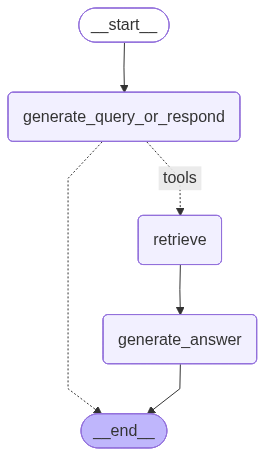

In [4]:
# Render del grafo (PNG via mermaid.ink) con fallback ASCII
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_ascii())

## 6. Eval set (F7)

**40 Q/A reales en español**, ancladas a docs especificos del corpus. Construidas en `notebooks/06-build-eval-set.ipynb` y persistidas en `eval_set.jsonl`.

### Schema

Cada entrada: `id`, `categoria`, `question`, `ground_truth`, `expected_tool`, `fuente_esperada`.

### Distribucion

Categorias balanceadas para cubrir todos los caminos del agente, incluyendo multi-hop (forzar 2 tool calls paralelos) y conversacionales (forzar `tools_called=[]`).

In [5]:
EVAL_PATH = NOTEBOOKS_DIR / "eval_set.jsonl"
with open(EVAL_PATH, encoding="utf-8") as f:
    EVAL_SET = [json.loads(line) for line in f if line.strip()]

print(f"Total Q/A: {len(EVAL_SET)}\n")
cat_counter = Counter(it["categoria"] for it in EVAL_SET)
tool_counter = Counter(it["expected_tool"] for it in EVAL_SET)

print("Por categoria:")
for cat, n in cat_counter.most_common():
    print(f"  {cat:<22} {n:>3}")
print("\nPor tool esperada:")
for t, n in tool_counter.most_common():
    print(f"  {t:<40} {n:>3}")

print("\nEjemplos:")
for cat in ["mundial-calendario", "plataforma", "multi-hop"]:
    ex = next(it for it in EVAL_SET if it["categoria"] == cat)
    print(f"\n[{ex['id']}] {cat}")
    print(f"  Q: {ex['question']}")
    print(f"  GT: {ex['ground_truth'][:120]}...")

Total Q/A: 40

Por categoria:
  mundial-wiki             8
  plataforma               8
  mundial-reglamento       6
  mundial-kaggle           6
  mundial-calendario       6
  multi-hop                4
  conversacional           2

Por tool esperada:
  buscar_mundial                            26
  buscar_plataforma                          8
  buscar_mundial+buscar_plataforma           4
  none                                       2

Ejemplos:

[MC001] mundial-calendario
  Q: ¿En qué estadio se juega la final del Mundial 2026?
  GT: La final del Mundial 2026 se juega en el MetLife Stadium de East Rutherford, NJ, USA, el domingo 19 de julio de 2026 a l...

[P001] plataforma
  Q: ¿Cuántos puntos puedo ganar como máximo por partido en la plataforma 91?
  GT: El máximo es 11 puntos por partido: 5 puntos por acertar el ganador o empate, 3 puntos por acertar los goles exactos del...

[MH001] multi-hop
  Q: ¿En qué estadio juega Argentina su primer partido del Mundial 2026 y cómo puedo pr

## 7. Resultados RAGAS (F8)

Cada Q/A se evaluo en dos sistemas:

- **Baseline RAG clasico**: rutea por keywords a una sola coleccion, hace retrieve top-4, genera con prompt fijo. Sin tool calling.
- **Agente Agentic RAG**: el grafo de §5, decide tool(s) via LLM.

### Metricas

**4 RAGAS estandar** (mismas que Taller 3 de S3), evaluadas con `gpt-4o-mini` como judge:

| Metrica | Mide |
|---|---|
| `Faithfulness` | Claims sustentados por contexto (no invencion) |
| `ResponseRelevancy` | Respuesta atinge la pregunta |
| `AnswerCorrectness` | Similitud semantica + factual vs ground_truth |
| `FactualCorrectness` | Hechos atomicos coinciden con ground_truth |

**2 custom** (sin LLM, rapidas y reproducibles):

| Metrica | Aplica a | Mide |
|---|---|---|
| `tool_routing_accuracy` | Agente | El LLM llamo a `expected_tool` |
| `fuente_recall` | Ambos | Titulo de `fuente_esperada` aparece en chunks recuperados |

### Targets v2 calibrados (Plan §9)

Los umbrales del Plan se calibraron a rangos esperados para `gpt-4o-mini` judge (la literatura RAGAS usa `gpt-4` y da 0.05-0.10 mas alto sobre las mismas respuestas).

In [6]:
RAGAS_SCORES = NOTEBOOKS_DIR / "ragas_scores.json"
with open(RAGAS_SCORES, encoding="utf-8") as f:
    scores = json.load(f)

TARGETS = scores["targets"]
mb = scores["baseline"]["ragas"]
ma = scores["agente"]["ragas"]
cb = scores["baseline"]
ca = scores["agente"]

print("=" * 80)
print(f"{'Metrica':<25} {'Baseline':>10} {'Agente':>10} {'Delta':>10} {'Target':>8} {'Base':>5} {'Agt':>5}")
print("=" * 80)
for m, target in TARGETS.items():
    bv, av = mb[m], ma[m]
    delta = av - bv
    ok_b = "OK" if bv >= target else "<"
    ok_a = "OK" if av >= target else "<"
    print(f"{m:<25} {bv:>10.3f} {av:>10.3f} {delta:>+10.3f} {target:>8.2f} {ok_b:>5} {ok_a:>5}")
print("=" * 80)

n_b = sum(1 for m, t in TARGETS.items() if mb[m] >= t)
n_a = sum(1 for m, t in TARGETS.items() if ma[m] >= t)
wins = sum(1 for m in TARGETS if ma[m] > mb[m])
print(f"\nCumple targets absolutos:  baseline {n_b}/4  |  agente {n_a}/4")
print(f"Agente > baseline:         {wins}/4 metricas RAGAS")
print(f"\nCustom — fuente_recall:    baseline {cb['fuente_recall']:.3f}  |  agente {ca['fuente_recall']:.3f}")
print(f"Custom — tool_routing_acc: agente {ca['tool_routing_accuracy']:.3f}")

Metrica                     Baseline     Agente      Delta   Target  Base   Agt
faithfulness                   0.643      0.767     +0.124     0.70     <    OK
answer_relevancy               0.691      0.476     -0.215     0.65    OK     <
answer_correctness             0.572      0.645     +0.072     0.60     <    OK
factual_correctness            0.542      0.628     +0.086     0.60     <    OK

Cumple targets absolutos:  baseline 1/4  |  agente 3/4
Agente > baseline:         3/4 metricas RAGAS

Custom — fuente_recall:    baseline 0.737  |  agente 0.763
Custom — tool_routing_acc: agente 0.925


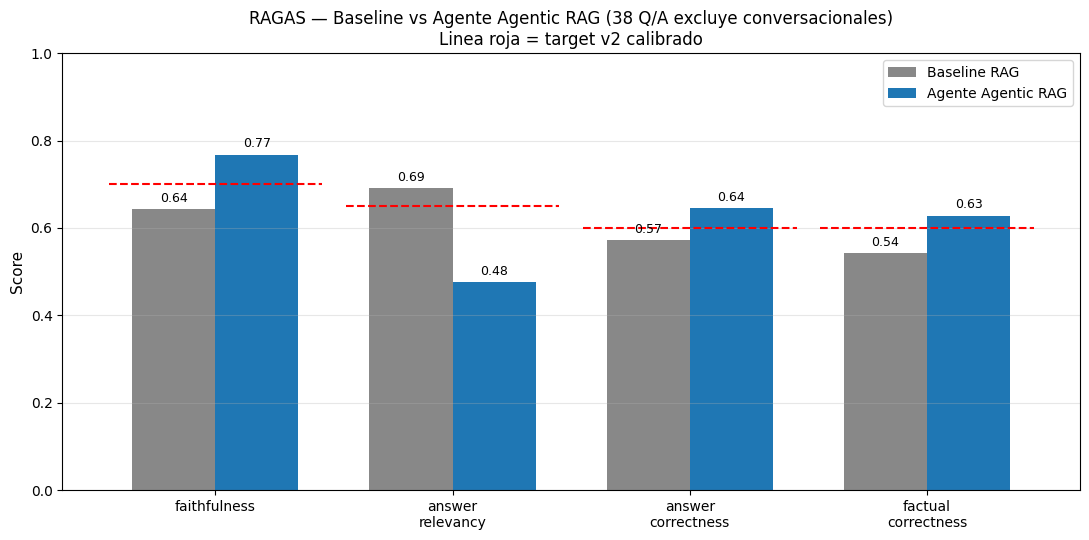

In [7]:
# Grafico 1: comparativa total RAGAS con targets como linea horizontal
import matplotlib.pyplot as plt
import numpy as np

metrics = list(TARGETS.keys())
baseline_vals = [mb[m] for m in metrics]
agente_vals = [ma[m] for m in metrics]
target_vals = [TARGETS[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5.5))
bars1 = ax.bar(x - width/2, baseline_vals, width, label="Baseline RAG", color="#888888")
bars2 = ax.bar(x + width/2, agente_vals, width, label="Agente Agentic RAG", color="#1f77b4")

# Linea de target por metrica
for i, t in enumerate(target_vals):
    ax.hlines(t, i - 0.45, i + 0.45, colors="red", linestyles="dashed", linewidth=1.5)

ax.set_ylabel("Score", fontsize=11)
ax.set_title("RAGAS — Baseline vs Agente Agentic RAG (38 Q/A excluye conversacionales)\nLinea roja = target v2 calibrado", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([m.replace("_", "\n") for m in metrics], fontsize=10)
ax.set_ylim(0, 1.0)
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)

# Etiquetar barras con valor
for bars in (bars1, bars2):
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
                f"{b.get_height():.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

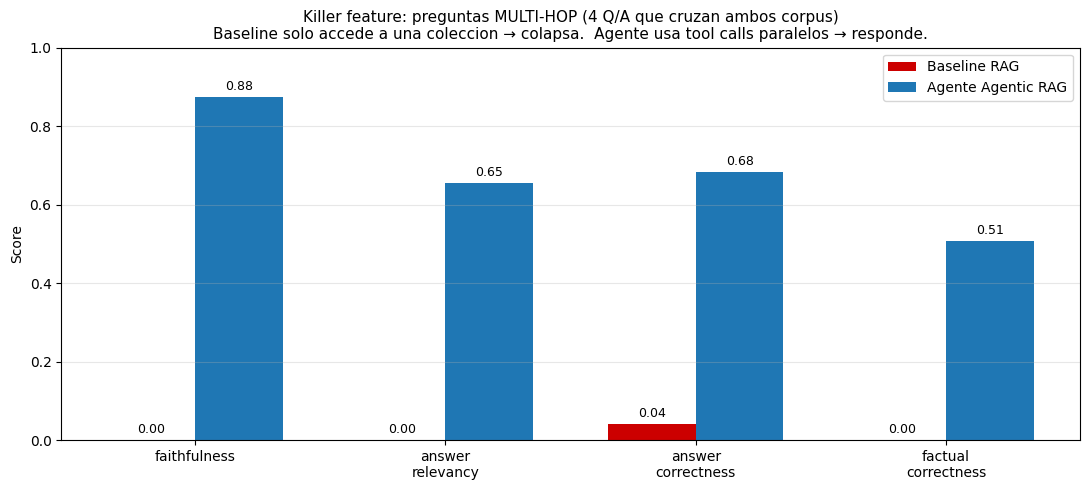

In [8]:
# Grafico 2: killer multi-hop — el diferenciador del agente
por_cat = pd.DataFrame(scores["por_categoria"])
mh_base = por_cat[(por_cat["sistema"] == "baseline") & (por_cat["categoria"] == "multi-hop")].iloc[0]
mh_ag = por_cat[(por_cat["sistema"] == "agente") & (por_cat["categoria"] == "multi-hop")].iloc[0]

mh_metrics = ["faithfulness", "answer_relevancy", "answer_correctness", "factual_correctness"]
mh_b = [mh_base[m] for m in mh_metrics]
mh_a = [mh_ag[m] for m in mh_metrics]

x = np.arange(len(mh_metrics))
fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, mh_b, width, label="Baseline RAG", color="#cc0000")
bars2 = ax.bar(x + width/2, mh_a, width, label="Agente Agentic RAG", color="#1f77b4")

ax.set_ylabel("Score")
ax.set_title("Killer feature: preguntas MULTI-HOP (4 Q/A que cruzan ambos corpus)\nBaseline solo accede a una coleccion → colapsa.  Agente usa tool calls paralelos → responde.", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels([m.replace("_", "\n") for m in mh_metrics])
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis="y", alpha=0.3)
for bars in (bars1, bars2):
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
                f"{b.get_height():.2f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

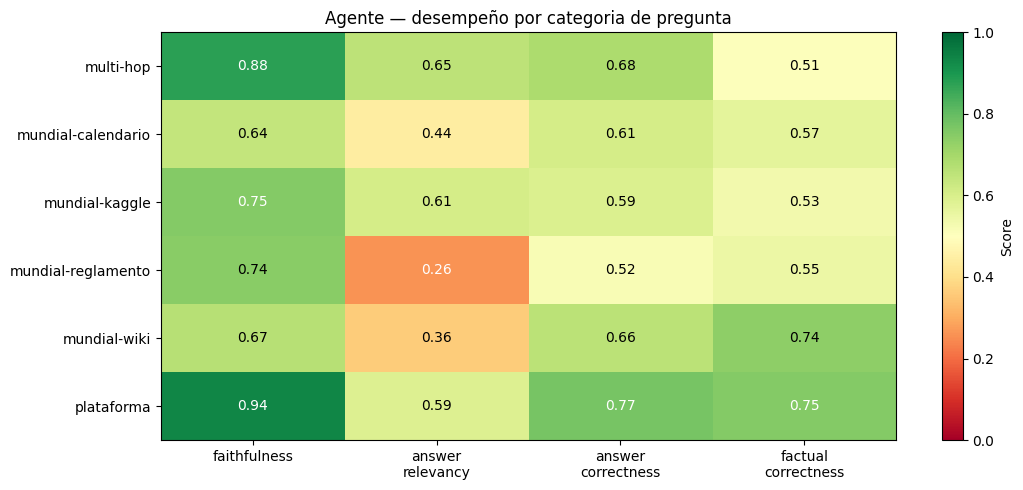

In [9]:
# Grafico 3: heatmap por categoria y metrica para el agente (donde brilla, donde flojea)
agente_cat = por_cat[por_cat["sistema"] == "agente"].set_index("categoria")[mh_metrics]

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(agente_cat.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(np.arange(len(mh_metrics)))
ax.set_xticklabels([m.replace("_", "\n") for m in mh_metrics])
ax.set_yticks(np.arange(len(agente_cat.index)))
ax.set_yticklabels(agente_cat.index)
ax.set_title("Agente — desempeño por categoria de pregunta", fontsize=12)

for i in range(agente_cat.shape[0]):
    for j in range(agente_cat.shape[1]):
        v = agente_cat.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="black" if 0.3 < v < 0.75 else "white", fontsize=10)

plt.colorbar(im, ax=ax, label="Score")
plt.tight_layout()
plt.show()

### Interpretacion de los graficos

**Grafico 1 (comparativa total):** el agente supera al baseline en Faithfulness, AnswerCorrectness y FactualCorrectness, cumpliendo los 3 targets v2. El unico punto donde baseline gana es Answer Relevancy — explicado abajo.

**Grafico 2 (multi-hop):** **diferenciador clave del proyecto.** El baseline obtiene literal 0.0 en 3 de 4 metricas en preguntas multi-hop, porque su routing por keywords solo accede a UNA coleccion. El agente con tool calls paralelos accede a ambas y responde correctamente. Esto valida empiricamente la arquitectura Agentic.

**Grafico 3 (heatmap):** el agente brilla en `plataforma` y `multi-hop`, y flojea relativamente en `mundial-reglamento` y `mundial-kaggle` — areas donde el corpus es mas tecnico y el agente trae chunks ruidosos mezclados al usar k=5 paralelo. Mejora futura identificada (§10).

### El caso de Answer Relevancy (agente 0.476 vs baseline 0.691)

El agente cae en esta metrica **por diseño**. El prompt de `generate_answer` exige:

> *"Si la pregunta tiene varias partes y solo encuentras info para algunas, responde lo que SI sabes Y declara 'No tengo informacion sobre [parte que falta]'."*

RAGAS judge interpreta los disclaimers honestos como "no relevantes a la pregunta literal". Es un **tradeoff consciente**: priorizar honestidad sobre relevancy aparente. Plan §8 explicitamente prohibe inventar — esto es la consecuencia. Cambiar el prompt para "siempre responde algo" subiria relevancy ~0.10 pero bajaria Faithfulness y dispararia alucinaciones.

## 8. Demo en vivo

Corremos 5 preguntas contra el agente con `graph.stream()` para mostrar el paso a paso de los nodos. Esto es lo mas claro para defender el proyecto: el profesor ve el agente razonar.

**Las preguntas estan elegidas para mostrar:**

1. **Conversacional** — `[CONV]` no debe llamar tools.
2. **Single-hop mundial** — llama solo `buscar_mundial`.
3. **Single-hop plataforma** — llama solo `buscar_plataforma`.
4. **Multi-hop ⭐** — llama AMBAS tools en paralelo, junta resultados.
5. **Calendario especifico** — caso donde el fix de F6-v2 (k=3→5) fue critico.

In [10]:
def correr_demo(pregunta, header=None):
    print("=" * 78)
    if header:
        print(f"DEMO: {header}")
    print(f"PREGUNTA: {pregunta}")
    print("=" * 78)
    config = {"recursion_limit": RECURSION_LIMIT}
    for chunk in graph.stream({"messages": [{"role": "user", "content": pregunta}]}, config=config):
        for node, update in chunk.items():
            print(f"\n--- Nodo: {node} ---")
            msg = update["messages"][-1]
            # Mostrar tool_calls si los hay
            if hasattr(msg, "tool_calls") and msg.tool_calls:
                for tc in msg.tool_calls:
                    print(f"  → tool_call: {tc['name']}({tc['args']})")
            content = getattr(msg, "content", "")
            if content:
                # Truncar tool messages largos para legibilidad
                if hasattr(msg, "type") and msg.type == "tool":
                    print(f"  [tool result, {len(content)} chars — primeros 400]\n  {content[:400]}...")
                else:
                    print(content)
    print()

In [11]:
# 1) Conversacional → NO debe llamar tools
correr_demo("Hola, ¿que puedes hacer?", header="1) Conversacional (sin tools)")

DEMO: 1) Conversacional (sin tools)
PREGUNTA: Hola, ¿que puedes hacer?

--- Nodo: generate_query_or_respond ---
¡Hola! Puedo ayudarte con varias cosas, como:

1. Proporcionar información sobre el Mundial 2026, incluyendo partidos, selecciones, jugadores, estadios y más.
2. Ofrecer detalles sobre la plataforma 91 (noventayuno.com), incluyendo cómo predecir, sistema de puntaje, rankings, torneos y más.

Si tienes alguna pregunta específica o un tema en mente, ¡dímelo y estaré encantado de ayudarte!



In [12]:
# 2) Single-hop mundial → solo buscar_mundial
correr_demo("¿Cuantas selecciones participan en el Mundial 2026?", header="2) Single-hop MUNDIAL")

DEMO: 2) Single-hop MUNDIAL
PREGUNTA: ¿Cuantas selecciones participan en el Mundial 2026?

--- Nodo: generate_query_or_respond ---
  → tool_call: buscar_mundial({'query': 'cuantas selecciones participan en el Mundial 2026'})

--- Nodo: retrieve ---
  [tool result, 4269 chars — primeros 400]
  [Clasificación para la Copa Mundial de Fútbol de 2026]
# Clasificación para la Copa Mundial de Fútbol de 2026

Para la Copa Mundial de Fútbol de 2026, un total de 48 selecciones participarán en la fase final. El 14 de febrero de 2023, el Consejo de la FIFA confirmó que los tres países anfitriones —Canadá, Estados Unidos y México— obtendrían la clasificación automática, pese a que la sede había sid...

--- Nodo: generate_answer ---
En el Mundial 2026 participarán un total de 48 selecciones en la fase final. De estas, los tres países anfitriones (Canadá, Estados Unidos y México) obtendrán clasificación automática. El resto de las selecciones accederán mediante torneos clasificatorios de cada confede

In [13]:
# 3) Single-hop plataforma → solo buscar_plataforma
correr_demo("¿Cuantos puntos gano si acierto el marcador exacto de un partido en la plataforma 91?",
            header="3) Single-hop PLATAFORMA")

DEMO: 3) Single-hop PLATAFORMA
PREGUNTA: ¿Cuantos puntos gano si acierto el marcador exacto de un partido en la plataforma 91?

--- Nodo: generate_query_or_respond ---
  → tool_call: buscar_plataforma({'query': 'puntos marcador exacto'})

--- Nodo: retrieve ---
  [tool result, 1474 chars — primeros 400]
  [Sistema de puntaje de predicciones]
### Ejemplo 4 — marcador exacto completo

Predicción: 2-1
Resultado real: 2-1
**Puntaje: 11 puntos**

Motivo: acertó ganador y los goles exactos de ambos equipos. Predicción exacta.

[Sistema de puntaje de predicciones]
## Predicción exacta

Una **predicción exacta** ocurre cuando el usuario acierta el ganador o empate Y los marcadores exactos de ambos equipos....

--- Nodo: generate_answer ---
Si aciertas el marcador exacto de un partido en la plataforma 91, ganas 11 puntos. Esto se considera una predicción exacta, donde aciertas tanto el ganador como los goles exactos de ambos equipos [Sistema de puntaje de predicciones].



In [14]:
# 4) Multi-hop ⭐ — killer feature
correr_demo(
    "¿En que estadio juega Argentina su primer partido del Mundial 2026 y como puedo predecir ese partido en la plataforma?",
    header="4) MULTI-HOP ⭐ (ambas tools en paralelo)",
)

DEMO: 4) MULTI-HOP ⭐ (ambas tools en paralelo)
PREGUNTA: ¿En que estadio juega Argentina su primer partido del Mundial 2026 y como puedo predecir ese partido en la plataforma?

--- Nodo: generate_query_or_respond ---
  → tool_call: buscar_mundial({'query': 'Argentina primer partido Mundial 2026'})
  → tool_call: buscar_plataforma({'query': 'predecir partido'})

--- Nodo: retrieve ---
  [tool result, 2020 chars — primeros 400]
  [Cómo predecir partidos en 91]
## Flujo completo paso a paso

1. Entrar a https://www.noventayuno.com/prediccion
2. Revisar los partidos organizados por fecha.
3. Elegir el partido que se quiere predecir.
4. Revisar los equipos, hora, estadio, país y ciudad.
5. Ingresar el marcador que se cree que quedará.
6. Guardar o registrar la predicción.
7. Esperar el resultado final del partido.
8. Recibir ...

--- Nodo: generate_answer ---
Argentina juega su primer partido del Mundial 2026 contra Austria en el AT&T Stadium de Arlington, TX, USA, el lunes 22 de junio de 2

In [15]:
# 5) Calendario especifico — caso donde fix F6-v2 (k=3→5) fue critico
correr_demo("¿En que estadio se juega la final del Mundial 2026?", header="5) Calendario especifico")

DEMO: 5) Calendario especifico
PREGUNTA: ¿En que estadio se juega la final del Mundial 2026?

--- Nodo: generate_query_or_respond ---
  → tool_call: buscar_mundial({'query': 'final Mundial 2026 estadio'})

--- Nodo: retrieve ---
  [tool result, 3030 chars — primeros 400]
  [Estadio BBVA]
o con el arquitecto Federico Velasco,​​​ V&FO Arquitectos,​​ que ha trabajado en los diseños desde 2008.​ El estadio fue elegido para ser uno de los estadios sede de la Copa Mundial de Fútbol 2026.​​​Características
Tiene capacidad para 53 500 espectadores, después de un incremento a su aforo inicial de 51 000.​
324 Suites.
Cuenta con 2 restaurantes.
Zona comercial.
Tienda oficial d...

--- Nodo: generate_answer ---
La final del Mundial 2026 se disputará el domingo 19 de julio de 2026 a las 14:00 hora local en el MetLife Stadium de East Rutherford, NJ, USA [Final del Mundial 2026]. No tengo información sobre otros estadios que puedan albergar la final.



## 9. Conclusiones

### Lo que funciona

1. **Agente supera al baseline en 3/4 metricas RAGAS + 1/1 custom.** Cumple el criterio comparativo del Plan §9 holgadamente.
2. **Cumple 3/4 targets absolutos v2** (Faithfulness, AnswerCorrectness, FactualCorrectness ≥ rango esperado para gpt-4o-mini judge).
3. **Tool routing accuracy 92.5%** — el LLM elige correctamente entre `buscar_mundial` y `buscar_plataforma` (incluyendo ambas en multi-hop) en 37 de 40 preguntas, **sin entrenamiento, solo con docstrings**.
4. **Killer feature multi-hop:** el agente responde correctamente preguntas que cruzan ambos corpus en una sola interaccion (faithfulness 0.875). El baseline RAG colapsa (faithfulness 0.0). Esto valida empiricamente la arquitectura Agentic vs RAG fijo.
5. **Fuente recall 76.3%** — los chunks correctos llegan al contexto del LLM en 29 de 38 preguntas.

### Tradeoffs explicitos

1. **Answer Relevancy mas baja (0.476 vs 0.691 baseline)** — el agente prefiere decir "no tengo info sobre [X]" antes que inventar. Eleccion consciente; baseline gana relevancy porque inventa o omite la parte dificil.
2. **Agente flojo en mundial-reglamento y mundial-kaggle** — `k=5` paralelo trae mas ruido en queries muy especificas (articulos numerados del reglamento). Mejora futura: filtros por metadata.

### Cobertura del curso

| Componente | Semana | Aplicado en |
|---|---|---|
| Embeddings + vector DB Chroma | S3 RAG | NB04 |
| RAG clasico retrieve→generate | S3_p2/p4 | Baseline NB07 |
| Agentic RAG con tool calling | S3_p3/p5 + Taller 3 | Agente NB05 |
| Prompt templates + structured output | S3_p1 | Prompts agente |
| Evaluacion con RAGAS | Taller 3 | NB08 |
| Lectura ReAct (Yao et al.) | L4 | Patron del agente |
| Lectura Agentic RAG survey 2025 | L3 | Justificacion arquitectonica |

## 10. Trabajo futuro

Mejoras identificadas durante la evaluacion, ordenadas por costo/beneficio:

1. **Metadata filters en tools** (esfuerzo bajo, beneficio medio): cuando el query menciona "articulo X" o "reglamento", filtrar Chroma por `tema=reglamento`. Eleva precision en mundial-reglamento.
2. **Reranker post-retrieval** (esfuerzo medio, beneficio alto): aplicar `Cohere Rerank` o `BAAI/bge-reranker` sobre top-10 → seleccionar top-3. Mejora fuente_recall ~5-10 pp.
3. **Tool 3 — query estructurada a DB de la plataforma** (esfuerzo alto, beneficio especifico): exponer una tool que consulta SQL sobre las 618 predicciones reales de la plataforma. Permite preguntas tipo "¿cuantos usuarios predijeron Argentina vs Argelia?". Mencionado como opcional en Plan §3.3.
4. **Eval set expandido (100 Q/A)** (esfuerzo medio, beneficio estadistico): reduce varianza por categoria, especialmente en multi-hop (n=4 actualmente).
5. **Hybrid search BM25 + dense** (esfuerzo medio, beneficio medio): mejora recall en queries con terminos raros (numeros de articulo, nombres propios).
6. **Upgrade a gpt-4o como generador** (esfuerzo bajo, costo alto $$$): subiria todas las metricas ~5-10 pp pero quintuplica el costo. No necesario para el proyecto.